Exploring **AlexNet** architecture on the Tiny Images dataset over here

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

2026-09-11 18:38:18.462903: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-11 18:38:18.462998: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-11 18:38:18.464430: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-11 18:38:18.472142: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-11 18:38:19.669530: W tensorflow/compiler/tf2

### Getting the TinyImages Dataset

In [2]:
from pathlib import Path

data_dir= Path("tiny-imagenet-200")
data_dir.exists()

True

In [3]:
list(data_dir.iterdir())

[PosixPath('tiny-imagenet-200/test'),
 PosixPath('tiny-imagenet-200/train'),
 PosixPath('tiny-imagenet-200/val'),
 PosixPath('tiny-imagenet-200/wnids.txt'),
 PosixPath('tiny-imagenet-200/words.txt')]

In [4]:
words= data_dir / "words.txt"
with open(words) as f:
    lines = f.readlines()

print(len(lines))

82115


That's 82115 classes in the WordNet dataset.. we're using a subset of that which is in the wnids.txt file

In [5]:
wnids= data_dir/"wnids.txt"

with open(wnids) as f: 
    lines= f.readlines()

print(len(lines))

200


Yeah.. so 200 classes in our ImageNet dataset

In [6]:

train_dir = data_dir / "train"
val_dir = data_dir / "val"
test_dir = data_dir / "test"

train_images = list(train_dir.glob("*/*/*.JPEG"))
val_images = list(val_dir.glob("*.JPEG"))
test_images = list(test_dir.glob("*.JPEG"))

print("Train:", len(train_images))
print("Val:", len(val_images))
print("Test:", len(test_images))

Train: 100000
Val: 0
Test: 0


TinyImages test set does not come with any labels.. so we're gonna be using our validation as our test set

In [7]:
train_images[:5]

[PosixPath('tiny-imagenet-200/train/n01443537/images/n01443537_0.JPEG'),
 PosixPath('tiny-imagenet-200/train/n01443537/images/n01443537_1.JPEG'),
 PosixPath('tiny-imagenet-200/train/n01443537/images/n01443537_10.JPEG'),
 PosixPath('tiny-imagenet-200/train/n01443537/images/n01443537_100.JPEG'),
 PosixPath('tiny-imagenet-200/train/n01443537/images/n01443537_101.JPEG')]

In [8]:
labels= [p.parent.parent.name for p in train_images[:5]]

In [9]:
labels

['n01443537', 'n01443537', 'n01443537', 'n01443537', 'n01443537']

In [10]:
val_images = list((val_dir / "images").glob("*.JPEG"))

In [11]:
len(val_images)

10000

In [12]:
val_annotations = val_dir / "val_annotations.txt"

print(val_annotations.exists())

with open(val_annotations) as f:
    for _ in range(5):
        print(f.readline().strip())

True
val_0.JPEG	n03444034	0	32	44	62
val_1.JPEG	n04067472	52	55	57	59
val_2.JPEG	n04070727	4	0	60	55
val_3.JPEG	n02808440	3	3	63	63
val_4.JPEG	n02808440	9	27	63	48


In [13]:
from sklearn.model_selection import train_test_split

# Labels for the 100k training images
train_labels = [p.parent.parent.name for p in train_images]

# Split 100k training images into 90k train + 10k validation
train_paths, valid_paths, train_labels, valid_labels = train_test_split(
    train_images,
    train_labels,
    test_size=0.1,
    stratify=train_labels, # make sure test set has equal distribution of images
    random_state= 42
)

# Official Tiny ImageNet validation set becomes our test set
test_paths = val_images
test_labels = []

with open(val_annotations) as f:
    for line in f:
        parts = line.strip().split()
        test_labels.append(parts[1])

print("Train:", len(train_paths))
print("Validation:", len(valid_paths))
print("Test:", len(test_paths))

Train: 90000
Validation: 10000
Test: 10000


In [14]:
train_paths[:5]

[PosixPath('tiny-imagenet-200/train/n04146614/images/n04146614_173.JPEG'),
 PosixPath('tiny-imagenet-200/train/n02233338/images/n02233338_413.JPEG'),
 PosixPath('tiny-imagenet-200/train/n03854065/images/n03854065_340.JPEG'),
 PosixPath('tiny-imagenet-200/train/n07734744/images/n07734744_261.JPEG'),
 PosixPath('tiny-imagenet-200/train/n02281406/images/n02281406_439.JPEG')]

In [15]:
train_labels[:5]

['n04146614', 'n02233338', 'n03854065', 'n07734744', 'n02281406']

Just turning the n0... representations to 0-200 classes

In [16]:
# Get the 200 Tiny ImageNet class IDs
with open(data_dir / "wnids.txt") as f:
    class_ids = [line.strip() for line in f if line.strip()]

# Create WordNet ID -> description dictionary
wordnet_classes = {}

with open(data_dir / "words.txt") as f:
    for line in f:
        wordnet_id, description = line.strip().split("\t", 1)
        
        if wordnet_id in class_ids:
            wordnet_classes[wordnet_id] = description

print(len(wordnet_classes))

200


In [17]:
idx_to_wordnet = {
    i: wordnet_classes[class_id] for i, class_id in enumerate(class_ids)
}

In [18]:
class_to_idx = {class_id: i for i, class_id in enumerate(
    line.strip() for line in open(data_dir / "wnids.txt") if line.strip()
)}

train_labels = [class_to_idx[x] for x in train_labels]
valid_labels = [class_to_idx[x] for x in valid_labels]
test_labels = [class_to_idx[x] for x in test_labels]

print(train_labels[:5])
print(len(set(train_labels)))

[15, 48, 19, 107, 42]
200


yeah, our labels are perfect now

In [19]:
idx_to_wordnet

{0: 'Egyptian cat',
 1: 'reel',
 2: 'volleyball',
 3: 'rocking chair, rocker',
 4: 'lemon',
 5: 'bullfrog, Rana catesbeiana',
 6: 'basketball',
 7: 'cliff, drop, drop-off',
 8: 'espresso',
 9: "plunger, plumber's helper",
 10: 'parking meter',
 11: 'German shepherd, German shepherd dog, German police dog, alsatian',
 12: 'dining table, board',
 13: 'monarch, monarch butterfly, milkweed butterfly, Danaus plexippus',
 14: 'brown bear, bruin, Ursus arctos',
 15: 'school bus',
 16: 'pizza, pizza pie',
 17: 'guinea pig, Cavia cobaya',
 18: 'umbrella',
 19: 'organ, pipe organ',
 20: 'oboe, hautboy, hautbois',
 21: 'maypole',
 22: 'goldfish, Carassius auratus',
 23: 'potpie',
 24: 'hourglass',
 25: 'seashore, coast, seacoast, sea-coast',
 26: 'computer keyboard, keypad',
 27: 'Arabian camel, dromedary, Camelus dromedarius',
 28: 'ice cream, icecream',
 29: 'nail',
 30: 'space heater',
 31: 'cardigan',
 32: 'baboon',
 33: 'snail',
 34: 'coral reef',
 35: 'albatross, mollymawk',
 36: "spider we

So these are our classes.. I'm particulary interested in the Espresso one

### Getting the Damn Images

In [20]:
# import numpy as np
# from PIL import Image

# def load_images(paths):
#     return np.array([
#         np.array(Image.open(path).convert("RGB"))
#         for path in paths
#     ], dtype=np.uint8)

In [21]:
# X_train = load_images(train_paths)
# X_valid = load_images(valid_paths)
# X_test = load_images(test_paths)

# y_train = np.array(train_labels)
# y_valid = np.array(valid_labels)
# y_test = np.array(test_labels)

In [22]:
# numpy_dir = Path("numpy_data")
# numpy_dir.mkdir(exist_ok=True)

# np.save(numpy_dir / "X_train.npy", X_train)
# np.save(numpy_dir / "y_train.npy", y_train)

# np.save(numpy_dir / "X_valid.npy", X_valid)
# np.save(numpy_dir / "y_valid.npy", y_valid)

# np.save(numpy_dir / "X_test.npy", X_test)
# np.save(numpy_dir / "y_test.npy", y_test)

In [23]:
numpy_dir = Path("numpy_data")

X_train = np.load(numpy_dir / "X_train.npy")
y_train = np.load(numpy_dir / "y_train.npy")

X_valid = np.load(numpy_dir / "X_valid.npy")
y_valid = np.load(numpy_dir / "y_valid.npy")

X_test = np.load(numpy_dir / "X_test.npy")
y_test = np.load(numpy_dir / "y_test.npy")

In [24]:
X_train.shape

(90000, 64, 64, 3)

Text(0.5, 1.0, 'cockroach, roach')

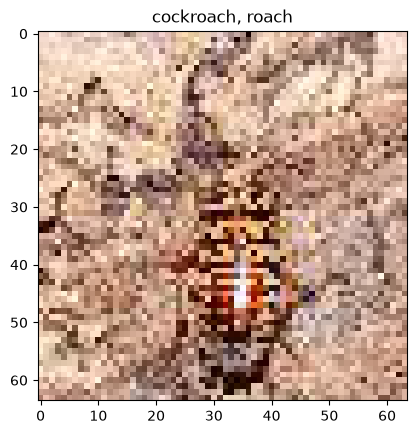

In [25]:
plt.imshow(X_train[1])
plt.title(idx_to_wordnet[y_train[1]])

Yeah.. we can see why even the best models struggle to cross lower than 18% error now ...

Yeah.. so i wanna see *Espresso*

In [26]:
(y_train == 8)

array([False, False, False, ..., False, False, False])

In [27]:
esp_idx = np.where([idx_to_wordnet[y] == 'espresso' for y in y_train])[0]

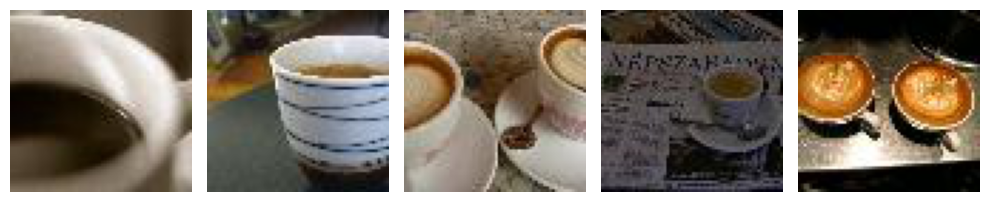

In [28]:
fig, axes= plt.subplots(1, 5, figsize= (10,15))
indices= np.random.choice(esp_idx, 5, replace= False)

for (i, ax) in zip(indices, axes.ravel()):
    ax.imshow(X_train[i])
    ax.axis("off")

plt.tight_layout()

Man.. most of these are'nt even Espresso.... I'm disappointed

Anyways.. let's just look at some images

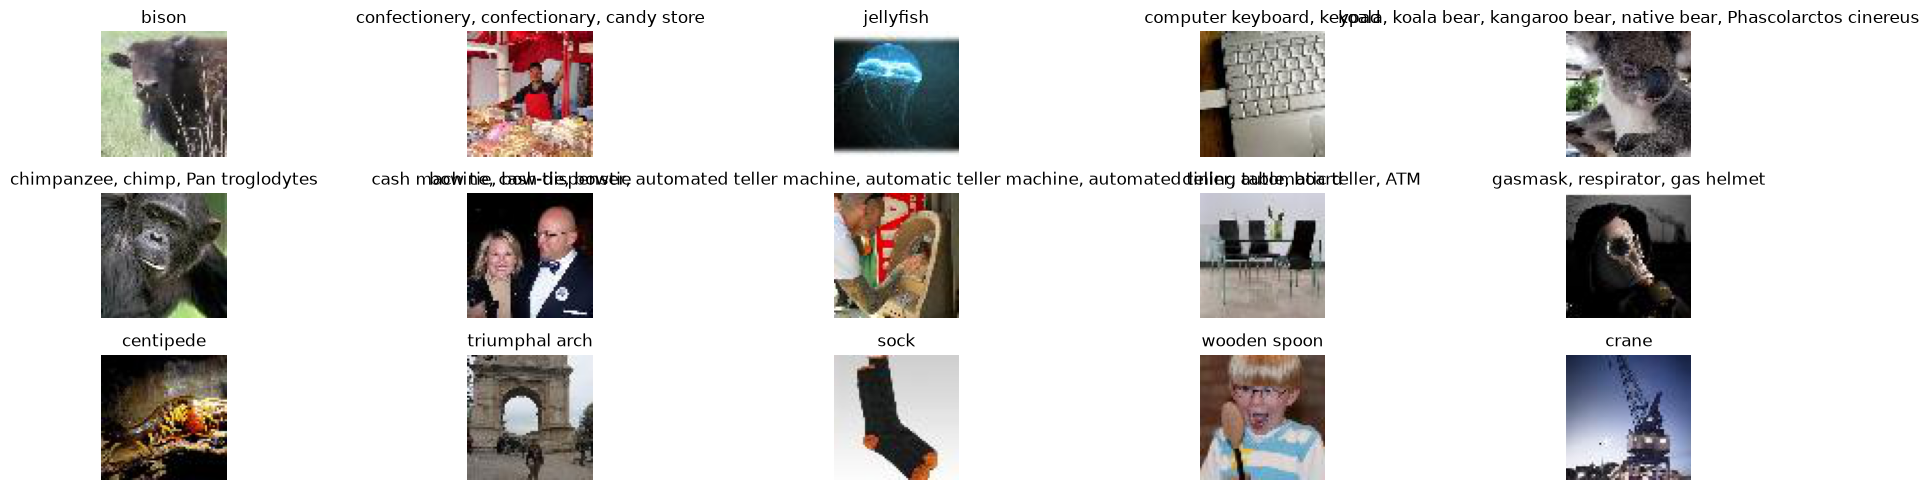

In [29]:
fig, axes= plt.subplots(3,5, figsize= (20,5))

indices= np.random.choice(90000, 15, replace= False)

for (i, ax) in zip(indices, axes.ravel()):
    ax.imshow(X_train[i])
    ax.set_title(idx_to_wordnet[y_train[i]])
    ax.axis("off")

plt.tight_layout()

Gotta get myself a "sombrero", huh

### Implementing AlexNet Architecture

Ok.. coming directly onto the good stuff.. here we go

In [30]:
X_train[1].shape

(64, 64, 3)

In [31]:
X_train[1][1][:5]

array([[245, 219, 206],
       [245, 219, 206],
       [251, 225, 212],
       [255, 229, 216],
       [240, 214, 201]], dtype=uint8)

Yeah... so as expected, gotta **Normalize** them

In [32]:
AlexNet = tf.keras.Sequential([
    tf.keras.layers.Resizing(227, 227, input_shape=(64, 64, 3)), #AlexNet uses 227 x 227 x 3 sized images
    tf.keras.layers.Rescaling(1./255), # Normalization

    #Layer1
    tf.keras.layers.Conv2D(96, 11, 4, activation='relu'),
    tf.keras.layers.MaxPooling2D(3, 2),

    #Layer2
    tf.keras.layers.Conv2D(256, 5, padding="same", activation='relu'),
    tf.keras.layers.MaxPooling2D(3,2),

    #Layers3-5
    tf.keras.layers.Conv2D(384, 3, padding="same", activation='relu'),
    tf.keras.layers.Conv2D(384, 3, padding="same", activation='relu'),
    tf.keras.layers.Conv2D(256, 3, padding="same", activation='relu'),
    
    tf.keras.layers.MaxPooling2D(3,2),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(2048, activation='relu'),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(200, activation= "softmax")
])

2026-09-11 18:38:32.781692: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-11 18:38:32.897811: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-11 18:38:32.898232: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-11 18:38:32.903248: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-11 18:38:32.903387: I external/local_xla/xla/stream_executor

In [33]:
AlexNet.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing (Resizing)         (None, 227, 227, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 227, 227, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 55, 55, 96)        34944     
                                                                 
 max_pooling2d (MaxPooling2  (None, 27, 27, 96)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 27, 27, 256)       614656    
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 13, 13, 256)       0         
 g2D)                                                   

In [34]:
AlexNet.compile(
    loss= ["sparse_categorical_crossentropy"], 
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    metrics= ["accuracy"]
)

In [35]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=8,
    restore_best_weights=True
)

In [36]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [37]:
history = AlexNet.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=50,
    batch_size=16,
    validation_batch_size=16,
    callbacks=[early_stop]
)

2026-09-11 18:38:34.097923: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1105920000 exceeds 10% of free system memory.
2026-09-11 18:38:36.493214: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1105920000 exceeds 10% of free system memory.


Epoch 1/50


2026-09-11 18:38:38.217831: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-09-11 18:38:38.391991: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-09-11 18:38:39.201853: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-09-11 18:38:39.319740: I external/local_xla/xla/service/service.cc:168] XLA service 0x771513bab4d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-11 18:38:39.319811: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
I0000 00:00:1789151919.412441    2667 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-09-11 18:38:40.680215: W external/local_tsl/tsl/framework/bfc_allocator.cc:296

5625/5625 [==============================] - 214s 37ms/step - loss: 5.0205 - accuracy: 0.0256 - val_loss: 4.6988 - val_accuracy: 0.0522
Epoch 2/50
5625/5625 [==============================] - 234s 42ms/step - loss: 4.4559 - accuracy: 0.0811 - val_loss: 4.2194 - val_accuracy: 0.1090
Epoch 3/50
5625/5625 [==============================] - 226s 40ms/step - loss: 4.0983 - accuracy: 0.1271 - val_loss: 4.0812 - val_accuracy: 0.1353
Epoch 4/50
5625/5625 [==============================] - 222s 39ms/step - loss: 3.9187 - accuracy: 0.1536 - val_loss: 4.0106 - val_accuracy: 0.1483
Epoch 5/50
5625/5625 [==============================] - 219s 39ms/step - loss: 3.8686 - accuracy: 0.1633 - val_loss: 4.0849 - val_accuracy: 0.1440
Epoch 6/50
5625/5625 [==============================] - 218s 39ms/step - loss: 3.9056 - accuracy: 0.1614 - val_loss: 4.2524 - val_accuracy: 0.1248
Epoch 7/50
5625/5625 [==============================] - 218s 39ms/step - loss: 4.0273 - accuracy: 0.1461 - val_loss: 4.4274 - val

KeyboardInterrupt: 

Okay.. Phew, we managed to train a model on GPU then.. that's a milestone

Obv, model is shit for now, but that was to be expected.. with 90k images.. we expect convergence at around 70 epochs.. + We gotta add something

Next up, increase batch size and introduce dropout in the Fully Connected Layer